Import de dataset y librerias

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from skforecast.recursive import ForecasterRecursive
import shap
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme
from skforecast.model_selection import backtesting_forecaster, TimeSeriesFold
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from skforecast.model_selection import grid_search_forecaster

dataset = 'CTC_processed.csv'
                              
data = pd.read_csv(
        dataset,
        sep=";",
        low_memory=False,
)

data = data.sort_index() #Ordenar por fecha

data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour
data["minute"] = data["datetime"].dt.minute

data.drop(columns=["datetime"], inplace=True) #eliminamos la columna Time

exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed', 'rain', 'pressure', 'month', 'day', 'hour', 'minute']


Dividimos en train y test

In [3]:
train_size = int(len(data) * 0.8)

data_train = data.iloc[:train_size]   
data_test  = data.iloc[train_size:]   

Obtenemos los parámetros óptimos del modelo

In [4]:
'''from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import random_search_forecaster
from xgboost import XGBRegressor
from skforecast.model_selection import TimeSeriesFold

param_distributions = {
    'learning_rate': [0.03, 0.1],
    'max_depth': [4, 6, 8],
    'n_estimators': [200, 400, 800],
    'subsample': [0.7, 1.0]
}

forecaster = ForecasterRecursive(
    estimator = XGBRegressor(
        n_jobs=-1,
        tree_method="hist"   # mucho más rápido
    ),
    lags = 7
)

cv = TimeSeriesFold(
    initial_train_size = int(len(data_train) * 0.2),  # más grande para menos folds
    steps = 366,
    gap = 0
)

search_result = random_search_forecaster(
    forecaster      = forecaster,
    y               = data_train['Power_gen'],
    exog            = data_train[exogenas],
    param_distributions = param_distributions,
    n_iter          = 10,          # solo 10 combinaciones
    cv              = cv,
    metric          = 'mean_absolute_error',
    return_best     = True,
    verbose         = True
)'''


'from skforecast.recursive import ForecasterRecursive\nfrom skforecast.model_selection import random_search_forecaster\nfrom xgboost import XGBRegressor\nfrom skforecast.model_selection import TimeSeriesFold\n\nparam_distributions = {\n    \'learning_rate\': [0.03, 0.1],\n    \'max_depth\': [4, 6, 8],\n    \'n_estimators\': [200, 400, 800],\n    \'subsample\': [0.7, 1.0]\n}\n\nforecaster = ForecasterRecursive(\n    estimator = XGBRegressor(\n        n_jobs=-1,\n        tree_method="hist"   # mucho más rápido\n    ),\n    lags = 7\n)\n\ncv = TimeSeriesFold(\n    initial_train_size = int(len(data_train) * 0.2),  # más grande para menos folds\n    steps = 366,\n    gap = 0\n)\n\nsearch_result = random_search_forecaster(\n    forecaster      = forecaster,\n    y               = data_train[\'Power_gen\'],\n    exog            = data_train[exogenas],\n    param_distributions = param_distributions,\n    n_iter          = 10,          # solo 10 combinaciones\n    cv              = cv,\n    met

El primer paso es crear el forecaster.

In [5]:
forecaster = ForecasterRecursive(
    estimator = XGBRegressor(learning_rate = 0.01, max_depth = 9, n_estimators = 900, subsample = 0.6),
    lags = 7
)

Entrenamos el forecaster

In [6]:
forecaster.fit(y=data_train['Power_gen'], exog=data_train[exogenas])

Obtenemos las variables mas importantes en el forecaster

In [7]:
importantes = forecaster.get_feature_importances()
print(importantes)

        feature  importance
0         lag_1    0.641062
8      solarRad    0.113849
15         hour    0.046869
13        month    0.031455
11         rain    0.016973
1         lag_2    0.015913
14          day    0.015679
3         lag_4    0.013236
6         lag_7    0.012880
5         lag_6    0.012820
9       humedad    0.012780
2         lag_3    0.012696
7   temperature    0.011788
4         lag_5    0.011702
10    windSpeed    0.011002
16       minute    0.010175
12     pressure    0.009120


Usamos SHAP para crear los datos de entrenamiento

In [8]:
x_train, y_train = forecaster.create_train_X_y(
    y=data_train['Power_gen'],
    exog=data_train[exogenas]
)

print(x_train.head()) 
print(y_train.head(3)) 

    lag_1  lag_2  lag_3  lag_4  lag_5  lag_6  lag_7  temperature  solarRad  \
7    68.0   70.0   69.0   78.0   82.0   70.0   65.0         18.1      97.0   
8    60.0   68.0   70.0   69.0   78.0   82.0   70.0         18.0      95.0   
9    61.0   60.0   68.0   70.0   69.0   78.0   82.0         18.0      93.0   
10   62.0   61.0   60.0   68.0   70.0   69.0   78.0         18.0      90.0   
11   57.0   62.0   61.0   60.0   68.0   70.0   69.0         18.2      86.0   

    humedad  windSpeed  rain  pressure  month   day  hour  minute  
7      52.0       17.7   0.0      29.9    1.0  24.0  14.0    10.0  
8      52.0       19.3   0.0      29.9    1.0  24.0  14.0    15.0  
9      52.0       20.9   0.0      29.9    1.0  24.0  14.0    20.0  
10     51.0       20.9   0.0      29.9    1.0  24.0  14.0    25.0  
11     49.0       14.5   0.0      29.9    1.0  24.0  14.0    30.0  
7    60
8    61
9    62
Name: y, dtype: int64


Explainer del SHAP

In [9]:
explainer = shap.Explainer(forecaster.estimator)

#50% de los datos de entrenamiento
rng = np.random.default_rng(42)
sample_indices = rng.choice(x_train.index, size=int(len(x_train) * 0.5), replace=False)
x_train_sample = x_train.loc[sample_indices,:]
shap_values = explainer.shap_values(x_train_sample)

Grafica resumen de SHAP

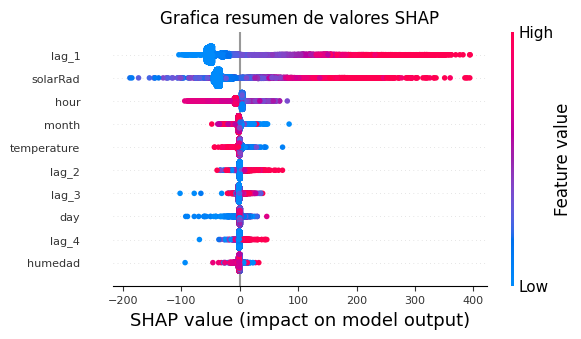

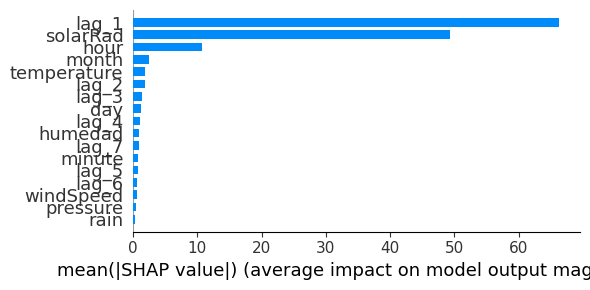

In [10]:
shap.initjs()
shap.summary_plot(shap_values, x_train_sample, max_display=10, show=False)
fig, ax = plt.gcf(), plt.gca()
ax.set_title('Grafica resumen de valores SHAP')
ax.tick_params(labelsize=8)
fig.set_size_inches(6,3)
plt.show()


plt.figure()
shap.summary_plot(shap_values, x_train, plot_type="bar", plot_size=(6, 3))
plt.show()

Grafica de dependencia

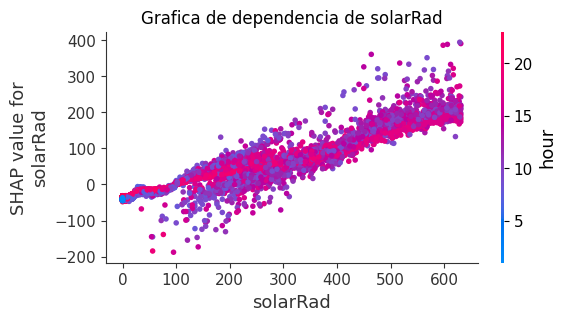

In [11]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_title('Grafica de dependencia de solarRad')

shap.dependence_plot("solarRad", shap_values, x_train_sample, ax=ax)
plt.show()

Ahora veremos las explicaciones de SHAP para predicciones de las proximas 8364 muestras (data_test)

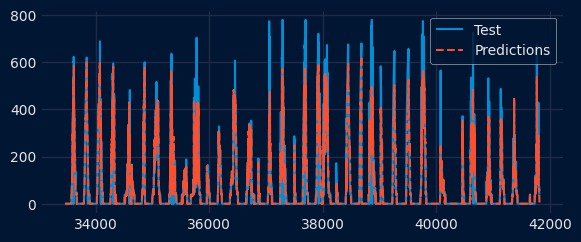

In [12]:
pred = forecaster.predict(steps=8364, exog=data_test[exogenas])
set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 2.5))
data_test['Power_gen'].plot(ax=ax, label='Test')
pred.plot(ax=ax, label='Predictions', linestyle='--')
ax.set_xlabel(None)
ax.legend()
plt.show()

Matriz de entrada para la prediccion de las proximas 8364 muestras.

In [13]:
x_predict = forecaster.create_predict_X(
    steps=8364,
    exog=data_test[exogenas]
)

Valores de SHAP para el backtesting_forecaster

In [14]:
cv = TimeSeriesFold(steps= 24, initial_train_size = len(data_train))
_, predictions = backtesting_forecaster(
                        forecaster        = forecaster,
                        y                 = data['Power_gen'],
                        exog              = data[exogenas],
                        cv                = cv,
                        metric            = 'mean_absolute_error',
                        return_predictors = True,
                )

predictions.head(3)

100%|██████████| 349/349 [00:37<00:00,  9.36it/s]


,fold,pred,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,temperature,solarRad,humedad,windSpeed,rain,pressure,month,day,hour,minute
33456,0,0.089135,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,22.1,0.0,75.0,1.61,0.0,30.2,8.0,8.0,22.0,16.0
33457,0,0.089135,0.089135,0.000000,0.0,0.0,0.0,0.0,0.0,22.1,0.0,75.0,0.00,0.0,30.2,8.0,8.0,22.0,21.0
33458,0,0.089135,0.089135,0.089135,0.0,0.0,0.0,0.0,0.0,22.1,0.0,75.0,3.22,0.0,30.2,8.0,8.0,22.0,26.0


Graficas de dependencia parcial.

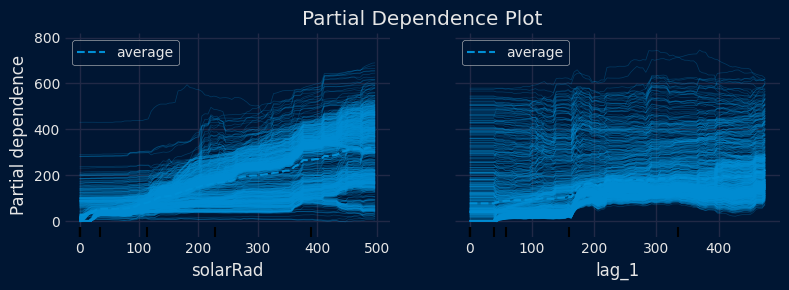

In [15]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = x_train,
    features  = ["solarRad", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout()
plt.show()

Metricas de la prediccion

In [16]:
y_test = data_test['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 14.5584
Mean Squared Error (MSE): 1617.5526
Root Mean Squared Error (RMSE): 40.2188
Coeficiente de determinación (R^2): 0.9207


Grafica comparativa realidad vs prediccion

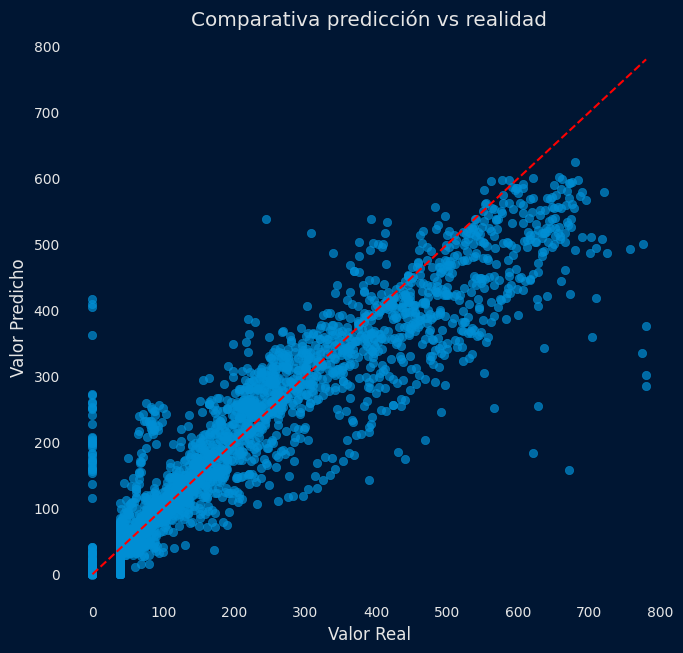

In [17]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()